# RNN Tutorials with Keras

This notebook contains two self-contained examples using recurrent neural networks (RNNs) with Keras (TensorFlow):

1. A simple sequence-to-sequence RNN for toy text translation (English → pseudo-French).
2. A simple RNN for 1-step-ahead stock price prediction on a synthetic time series.

These examples are meant as educational, minimal demonstrations, not production-ready models.


## Common setup

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.0


## Part 1: Toy text translation with an RNN sequence-to-sequence model

In this section we build a very small sequence-to-sequence model that learns to "translate"
a tiny set of English sentences into a pseudo-French language.

This is just a toy example to illustrate the encoder–decoder RNN architecture:

- **Encoder**: reads the source (English) sentence and produces a fixed-size state vector.
- **Decoder**: uses this state as initial state and generates the target (pseudo-French) sentence
  word by word.


### 1. Prepare a tiny parallel corpus

In [2]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tiny toy dataset: English → pseudo-French
pairs = [
    ("i like dogs",        "j aime les chiens"),
    ("i like cats",        "j aime les chats"),
    ("you like dogs",      "tu aimes les chiens"),
    ("you like cats",      "tu aimes les chats"),
    ("she loves dogs",     "elle aime les chiens"),
    ("she loves cats",     "elle aime les chats"),
    ("we like animals",    "nous aimons les animaux"),
    ("they like movies",   "ils aiment les films"),
    ("i love movies",      "j aime les films"),
    ("we love dogs",       "nous aimons les chiens"),
]

# Add <start> and <end> tokens on the target side
source_texts = [en for (en, fr) in pairs]
target_texts = [f"<start> {fr} <end>" for (en, fr) in pairs]

print("Example pair:")
print("EN:", source_texts[0])
print("FR:", target_texts[0])

Example pair:
EN: i like dogs
FR: <start> j aime les chiens <end>


### 2. Tokenize and vectorize source and target sentences

In [3]:
# Tokenize source (English)
src_tokenizer = Tokenizer(filters="")  # keep punctuation as-is (though we don't have any)
src_tokenizer.fit_on_texts(source_texts)
src_sequences = src_tokenizer.texts_to_sequences(source_texts)

# Tokenize target (pseudo-French)
trg_tokenizer = Tokenizer(filters="")
trg_tokenizer.fit_on_texts(target_texts)
trg_sequences = trg_tokenizer.texts_to_sequences(target_texts)

print("Source word index:", src_tokenizer.word_index)
print("Target word index:", trg_tokenizer.word_index)

# Pad sequences to same length
max_encoder_seq_length = max(len(seq) for seq in src_sequences)
max_decoder_seq_length = max(len(seq) for seq in trg_sequences)

encoder_input_data = pad_sequences(src_sequences, maxlen=max_encoder_seq_length, padding="post")
decoder_sequences = pad_sequences(trg_sequences, maxlen=max_decoder_seq_length, padding="post")

num_encoder_tokens = len(src_tokenizer.word_index) + 1  # +1 for padding index 0
num_decoder_tokens = len(trg_tokenizer.word_index) + 1

print("Max encoder length:", max_encoder_seq_length)
print("Max decoder length:", max_decoder_seq_length)
print("Num encoder tokens:", num_encoder_tokens)
print("Num decoder tokens:", num_decoder_tokens)

Source word index: {'like': 1, 'dogs': 2, 'i': 3, 'cats': 4, 'you': 5, 'she': 6, 'loves': 7, 'we': 8, 'movies': 9, 'love': 10, 'animals': 11, 'they': 12}
Target word index: {'<start>': 1, 'les': 2, '<end>': 3, 'aime': 4, 'chiens': 5, 'j': 6, 'chats': 7, 'tu': 8, 'aimes': 9, 'elle': 10, 'nous': 11, 'aimons': 12, 'films': 13, 'animaux': 14, 'ils': 15, 'aiment': 16}
Max encoder length: 3
Max decoder length: 6
Num encoder tokens: 13
Num decoder tokens: 17


We create decoder inputs and targets using **teacher forcing**:

- `decoder_input_data`: target sentence shifted right (starts with `<start>`).
- `decoder_target_data`: same sentence shifted left (predict next word), so model learns to
  predict the next token at each time step.


In [4]:
# Prepare decoder input (all tokens except the last)
decoder_input_data = decoder_sequences[:, :-1]
# Target is all tokens except the first
decoder_target_data = decoder_sequences[:, 1:]

print("Decoder input shape:", decoder_input_data.shape)
print("Decoder target shape:", decoder_target_data.shape)

Decoder input shape: (10, 5)
Decoder target shape: (10, 5)


### 3. Build the encoder–decoder RNN model

In [5]:
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense
from tensorflow.keras.models import Model

latent_dim = 64  # size of the RNN hidden state

# ----- Encoder -----
encoder_inputs = Input(shape=(None,), name="encoder_inputs")
encoder_embedding = Embedding(num_encoder_tokens, latent_dim, name="encoder_embedding")(encoder_inputs)
encoder_rnn = SimpleRNN(latent_dim, return_state=True, name="encoder_rnn")
_, encoder_state_h = encoder_rnn(encoder_embedding)

# ----- Decoder -----
decoder_inputs = Input(shape=(None,), name="decoder_inputs")
decoder_embedding_layer = Embedding(num_decoder_tokens, latent_dim, name="decoder_embedding")
decoder_embedding = decoder_embedding_layer(decoder_inputs)

decoder_rnn = SimpleRNN(latent_dim, return_sequences=True, return_state=True, name="decoder_rnn")
decoder_outputs, _ = decoder_rnn(decoder_embedding, initial_state=encoder_state_h)

decoder_dense = Dense(num_decoder_tokens, activation="softmax", name="decoder_dense")
decoder_outputs = decoder_dense(decoder_outputs)

# Full training model: [encoder_inputs, decoder_inputs] -> decoder_outputs
seq2seq_model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
seq2seq_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, None, 64)  │        832 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, None, 64)  │      1,088 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_rnn         │ [(None, 64),      │      8,256 │ encoder_embeddin… │
│ (SimpleRNN)         │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_rnn         │ [(None, None,     │      8,256 │ decoder_embeddin… │
│ (SimpleRNN)         │ 64), (None, 64)]  │            │ encoder_rnn[0][1] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, None, 17)  │      1,105 │ decoder_rnn[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,537 (76.32 KB)

 Trainable params: 19,537 (76.32 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Train the translation model

In [6]:
seq2seq_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = seq2seq_model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=16,
    epochs=300,
    verbose=0,
)

print("Training completed.")

Training completed.


### 5. Build inference models for actual translation

For inference, we need separate encoder and decoder models:

- **Encoder model**: maps an input sentence to the encoder state.
- **Decoder model**: takes the previous token and current state, and outputs the next token
  and updated state.

We then generate tokens one by one until we hit the `<end>` token.


In [7]:
# Encoder model for inference
encoder_model = Model(encoder_inputs, encoder_state_h)

# Decoder model for inference
decoder_state_input_h = Input(shape=(latent_dim,), name="decoder_state_input_h")
decoder_emb2 = decoder_embedding_layer(decoder_inputs)
decoder_outputs2, state_h2 = decoder_rnn(decoder_emb2, initial_state=decoder_state_input_h)
decoder_outputs2 = decoder_dense(decoder_outputs2)

decoder_model = Model(
    [decoder_inputs, decoder_state_input_h],
    [decoder_outputs2, state_h2],
)

# Index-to-word mapping for target language
index_to_trg_word = {i: w for w, i in trg_tokenizer.word_index.items()}
trg_word_to_index = trg_tokenizer.word_index

### 6. Utility function to decode new English sentences

In [8]:
def decode_sequence(input_sentence: str) -> str:
    # Vectorize input sentence
    seq = src_tokenizer.texts_to_sequences([input_sentence])
    seq = pad_sequences(seq, maxlen=max_encoder_seq_length, padding="post")
    state_value = encoder_model.predict(seq, verbose=0)

    # Start token for the target sequence
    start_index = trg_word_to_index.get("<start>")
    end_index = trg_word_to_index.get("<end>")

    target_seq = np.array([[start_index]])

    decoded_words = []
    for _ in range(max_decoder_seq_length):
        output_tokens, state_value = decoder_model.predict([target_seq, state_value], verbose=0)
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        if sampled_token_index == end_index or sampled_token_index == 0:
            break
        sampled_word = index_to_trg_word.get(sampled_token_index, "")
        decoded_words.append(sampled_word)

        # Update target sequence to contain the last predicted token
        target_seq = np.array([[sampled_token_index]])

    return " ".join(decoded_words)

### 7. Try translating a few sentences

In [9]:
test_sentences = [
    "i like cats",
    "you like dogs",
    "we love dogs",
    "they like movies",
]

for s in test_sentences:
    print("EN:", s)
    print("FR (pred):", decode_sequence(s))
    print("-")

EN: i like cats
FR (pred): j aime les chats
-
EN: you like dogs
FR (pred): tu aimes les chiens
-
EN: we love dogs
FR (pred): nous aimons les chiens
-
EN: they like movies
FR (pred): ils aiment les films
-


## Part 2: Stock price prediction with an RNN

In this section we create a simple RNN model that predicts the next time step
of a synthetic "stock price" series based on a sliding window of previous prices.

Steps:

1. Generate a synthetic stock price series (random walk + trend).
2. Turn it into supervised learning data using fixed-size windows.
3. Split into training / test sets.
4. Train a simple RNN regression model.
5. Evaluate and visualize predictions vs. actual prices.


### 1. Generate a synthetic stock price series

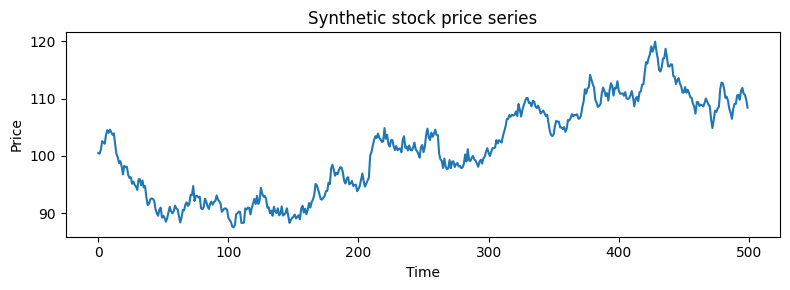

In [10]:
def generate_synthetic_stock_prices(
    n_points: int = 500,
    start_price: float = 100.0,
    drift: float = 0.01,
    volatility: float = 1.0,
):
    """Generate a simple synthetic stock price series using a random walk."""
    returns = np.random.normal(loc=drift, scale=volatility, size=n_points)
    prices = start_price + np.cumsum(returns)
    return prices

prices = generate_synthetic_stock_prices()
time = np.arange(len(prices))

plt.figure(figsize=(8, 3))
plt.plot(time, prices)
plt.title("Synthetic stock price series")
plt.xlabel("Time")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

### 2. Create sliding window sequences for supervised learning

In [11]:
def create_windowed_dataset(series, window_size: int = 20):
    X = []
    y = []
    for i in range(len(series) - window_size):
        X.append(series[i : i + window_size])
        y.append(series[i + window_size])
    X = np.array(X)
    y = np.array(y)
    # Add feature dimension for RNN: (samples, timesteps, features)
    X = X[..., np.newaxis]
    y = y[..., np.newaxis]
    return X, y

window_size = 20
X, y = create_windowed_dataset(prices, window_size=window_size)
print("Input shape:", X.shape)   # (samples, timesteps, features)
print("Target shape:", y.shape)

Input shape: (480, 20, 1)
Target shape: (480, 1)


### 3. Train/test split and normalization

In [12]:
split_frac = 0.8
split_index = int(len(X) * split_frac)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Normalize based on training data statistics
train_mean = X_train.mean()
train_std = X_train.std()

X_train_norm = (X_train - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Train samples: 384
Test samples: 96


### 4. Build and train an RNN regression model

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

rnn_model = Sequential(
    [
        SimpleRNN(32, input_shape=(window_size, 1)),
        Dense(16, activation="relu"),
        Dense(1),
    ]
)

rnn_model.summary()

rnn_model.compile(optimizer="adam", loss="mse" )

history_stock = rnn_model.fit(
    X_train_norm,
    y_train,
    epochs=400,
    batch_size=32,
    validation_split=0.2,
    verbose=0,
)

print("Training completed.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,633 (6.38 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 0 (0.00 B)

Training completed.


### 5. Plot training and validation loss

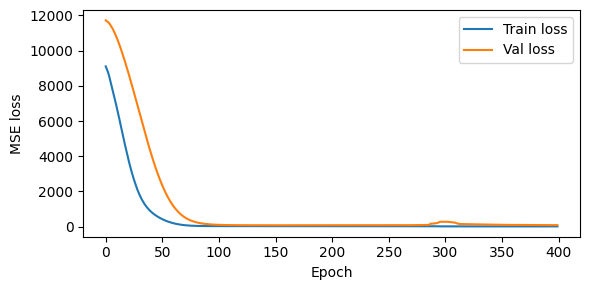

In [17]:
plt.figure(figsize=(6, 3))
plt.plot(history_stock.history["loss"], label="Train loss")
plt.plot(history_stock.history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.tight_layout()
plt.show()

### 6. Evaluate on test data and visualize predictions

Test MSE: 192.42752732376974


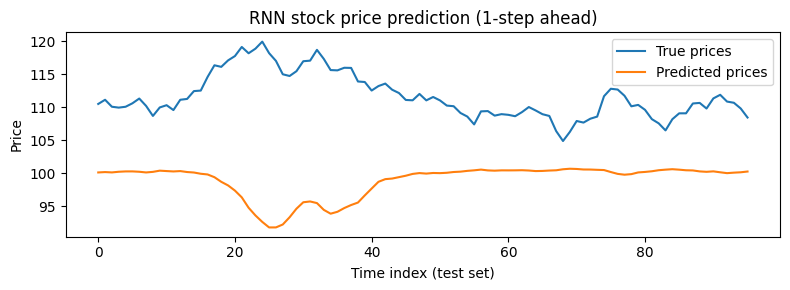

In [18]:
# Predict on normalized test inputs
y_pred = rnn_model.predict(X_test_norm, verbose=0)

test_mse = np.mean((y_test - y_pred) ** 2)
print("Test MSE:", float(test_mse))

plt.figure(figsize=(8, 3))
plt.plot(y_test.squeeze(), label="True prices")
plt.plot(y_pred.squeeze(), label="Predicted prices")
plt.title("RNN stock price prediction (1-step ahead)")
plt.xlabel("Time index (test set)")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()